# Day 2 – Exploratory Data Analysis

## Objective

The objective of Day 2 is to:

- Understand the sales distribution.
- Analyze trends over time.
- Identify top-performing categories.
- Analyze regional performance.
- Explore customer segments.
- Generate business insights through visualizations.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../data/processed/superstore_sales_processed.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])

print(df.shape)
df.head()

(9800, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Name,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,Autumn


In [25]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   str           
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

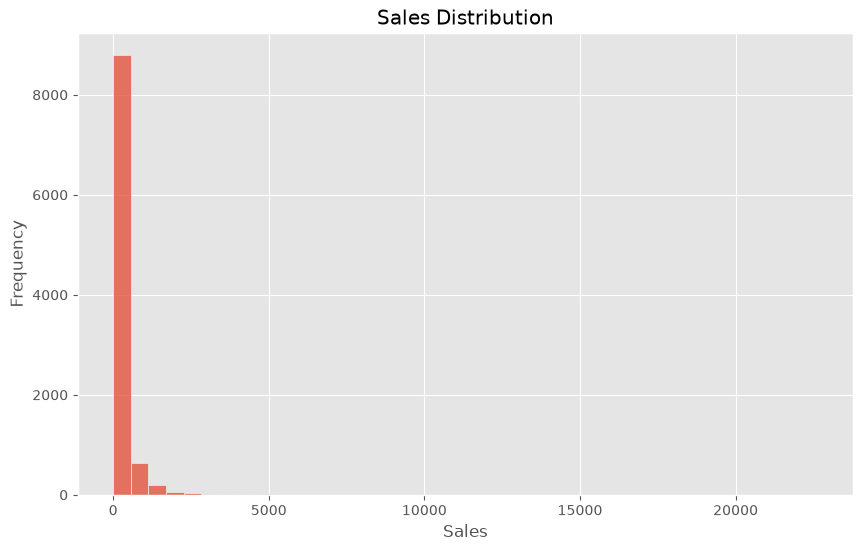

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=40)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("../charts/sales_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

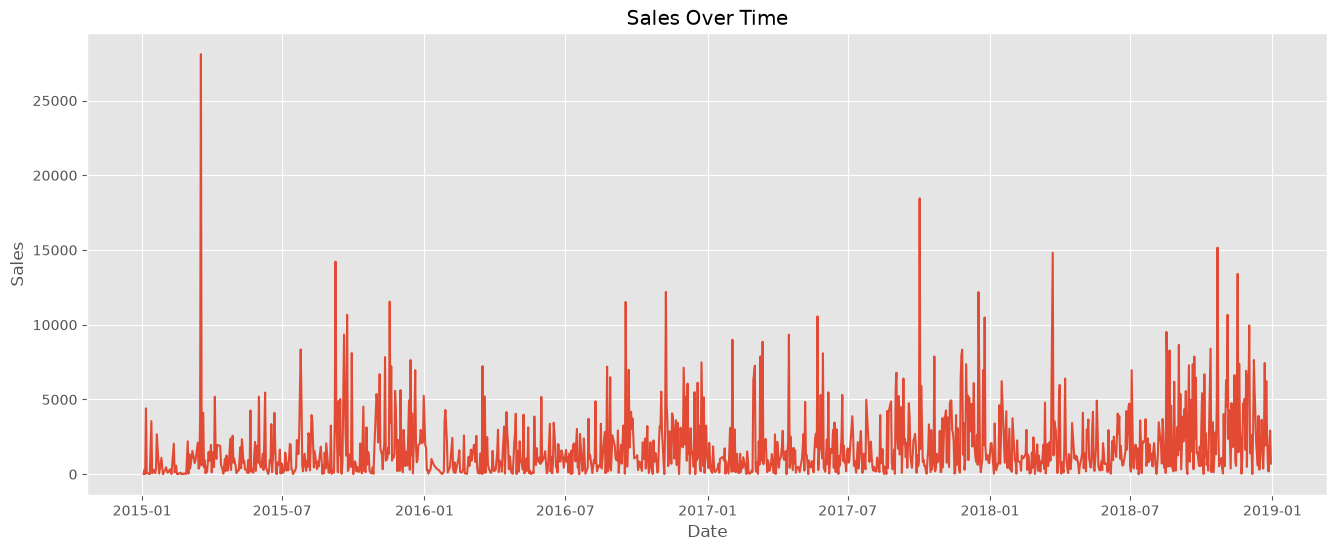

In [27]:
monthly_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("../charts/sales_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

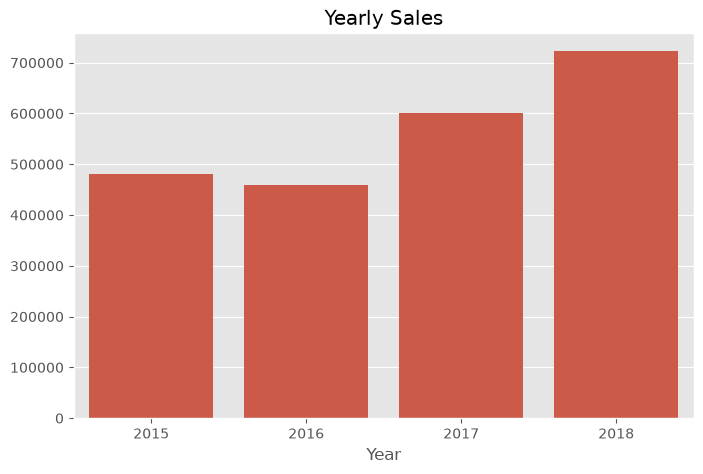

In [28]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title("Yearly Sales")
plt.savefig("../charts/yearly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

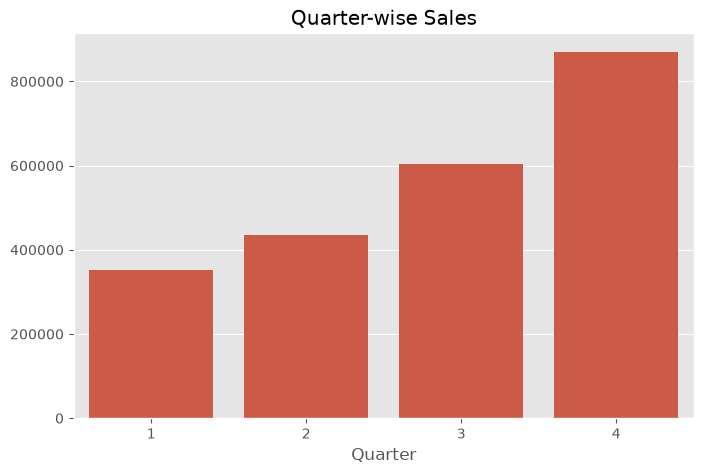

In [29]:
quarter_sales = (
    df.groupby("Quarter")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=quarter_sales.index,
    y=quarter_sales.values
)

plt.title("Quarter-wise Sales")
plt.savefig("../charts/quarterly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

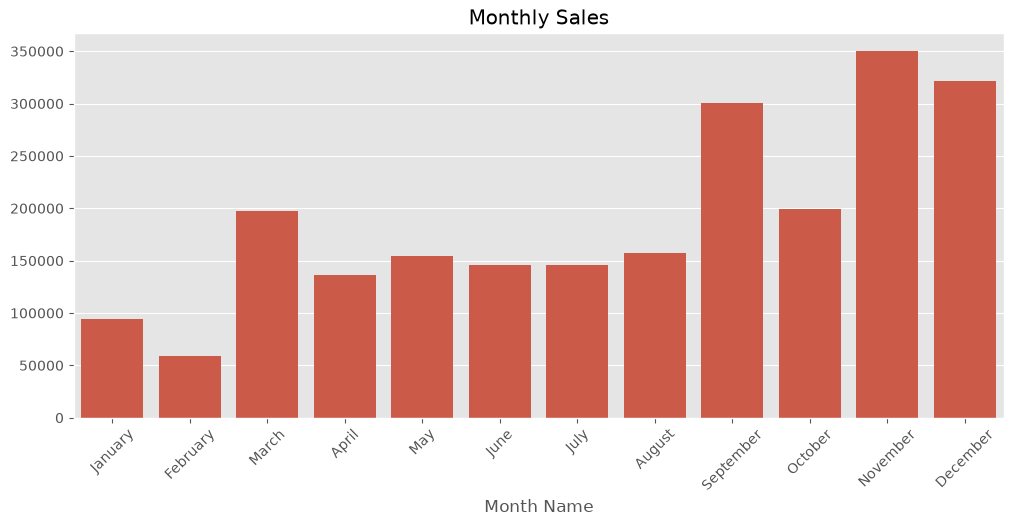

In [30]:
month_sales = (
    df.groupby("Month Name")["Sales"]
    .sum()
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_sales = month_sales.reindex(month_order)

plt.figure(figsize=(12,5))

sns.barplot(
    x=month_sales.index,
    y=month_sales.values
)

plt.xticks(rotation=45)

plt.title("Monthly Sales")
plt.savefig("../charts/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

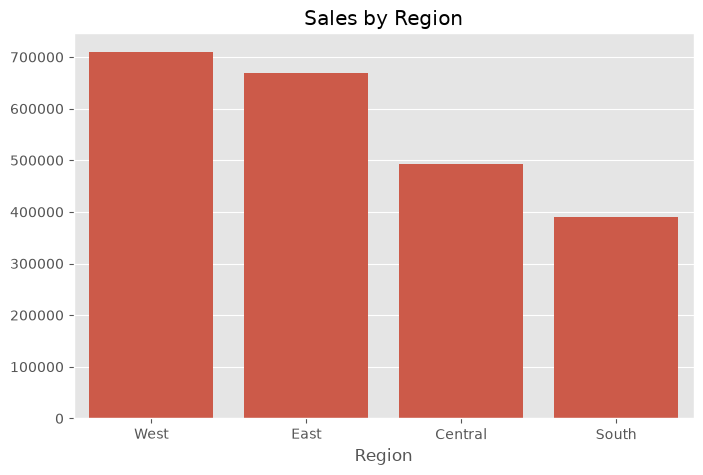

In [31]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.savefig("../charts/region_sales.png", dpi=300, bbox_inches="tight")
plt.show()

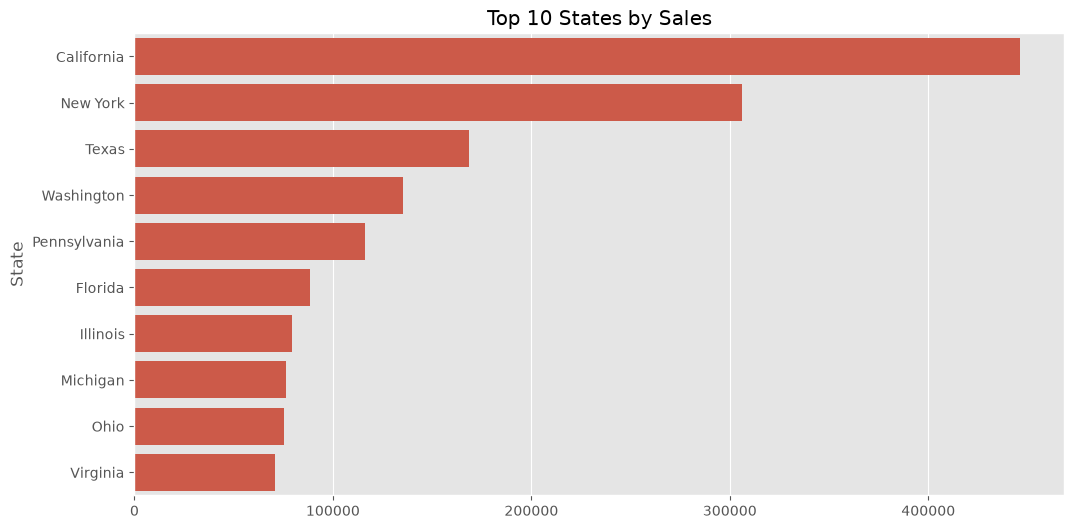

In [32]:
top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")
plt.savefig("../charts/top_states.png", dpi=300, bbox_inches="tight")

plt.show()

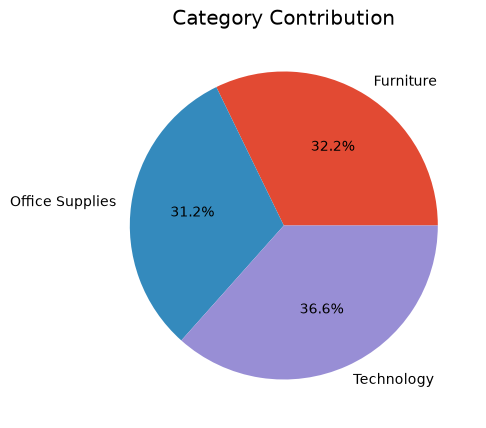

In [33]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%"
)

plt.title("Category Contribution")
plt.savefig("../charts/category_sales.png", dpi=300, bbox_inches="tight")

plt.show()

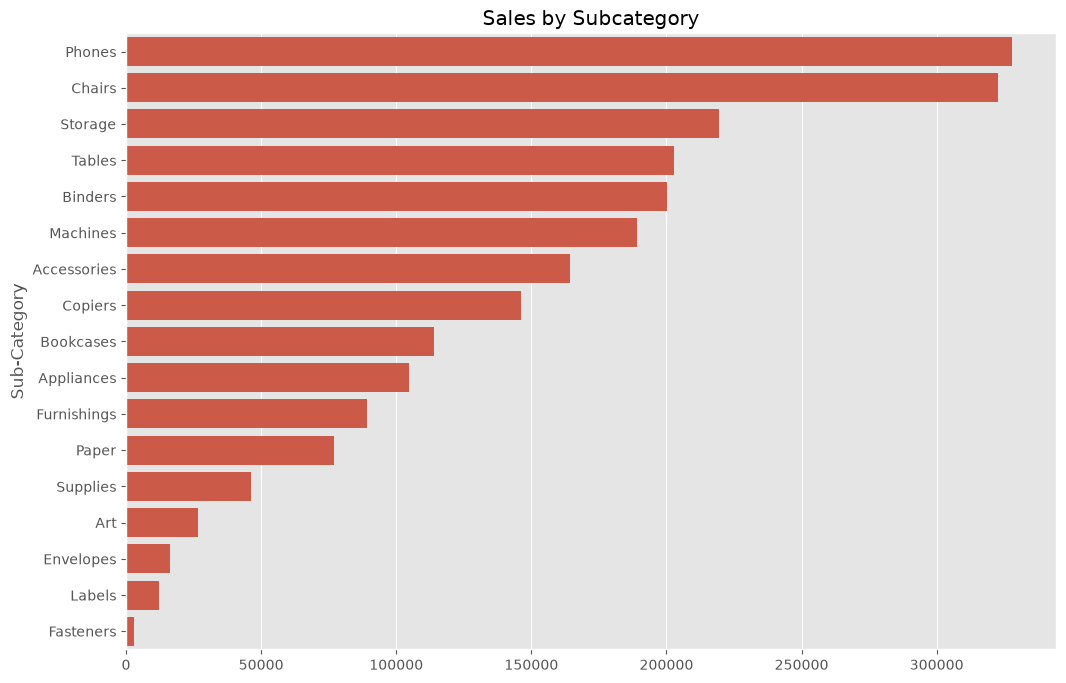

In [34]:
subcategory = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=subcategory.values,
    y=subcategory.index
)

plt.title("Sales by Subcategory")

plt.savefig("../charts/subcategory_sales.png", dpi=300, bbox_inches="tight")
plt.show()

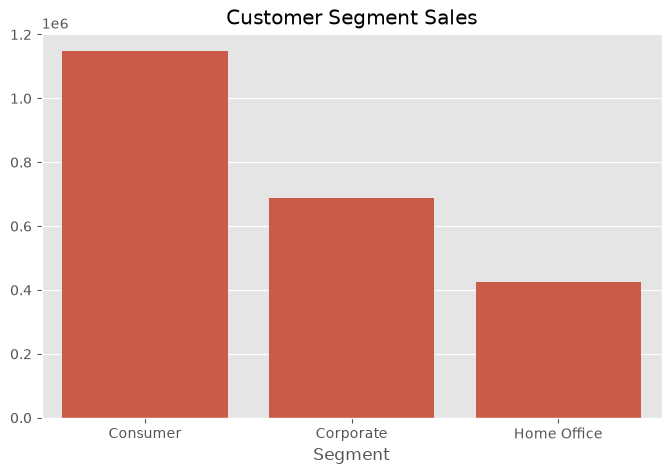

In [35]:
segment = (
    df.groupby("Segment")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment.index,
    y=segment.values
)

plt.title("Customer Segment Sales")

plt.savefig("../charts/segment_sales.png", dpi=300, bbox_inches="tight")

plt.show()

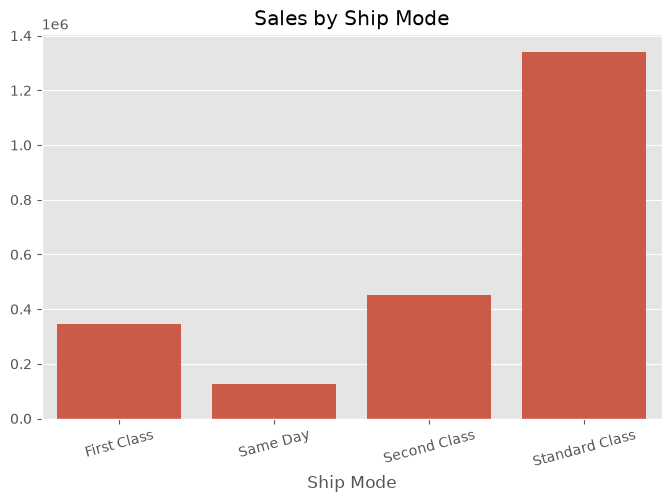

In [36]:
ship = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=ship.index,
    y=ship.values
)

plt.xticks(rotation=15)

plt.title("Sales by Ship Mode")

plt.savefig("../charts/shipping_mode.png", dpi=300, bbox_inches="tight")

plt.show()

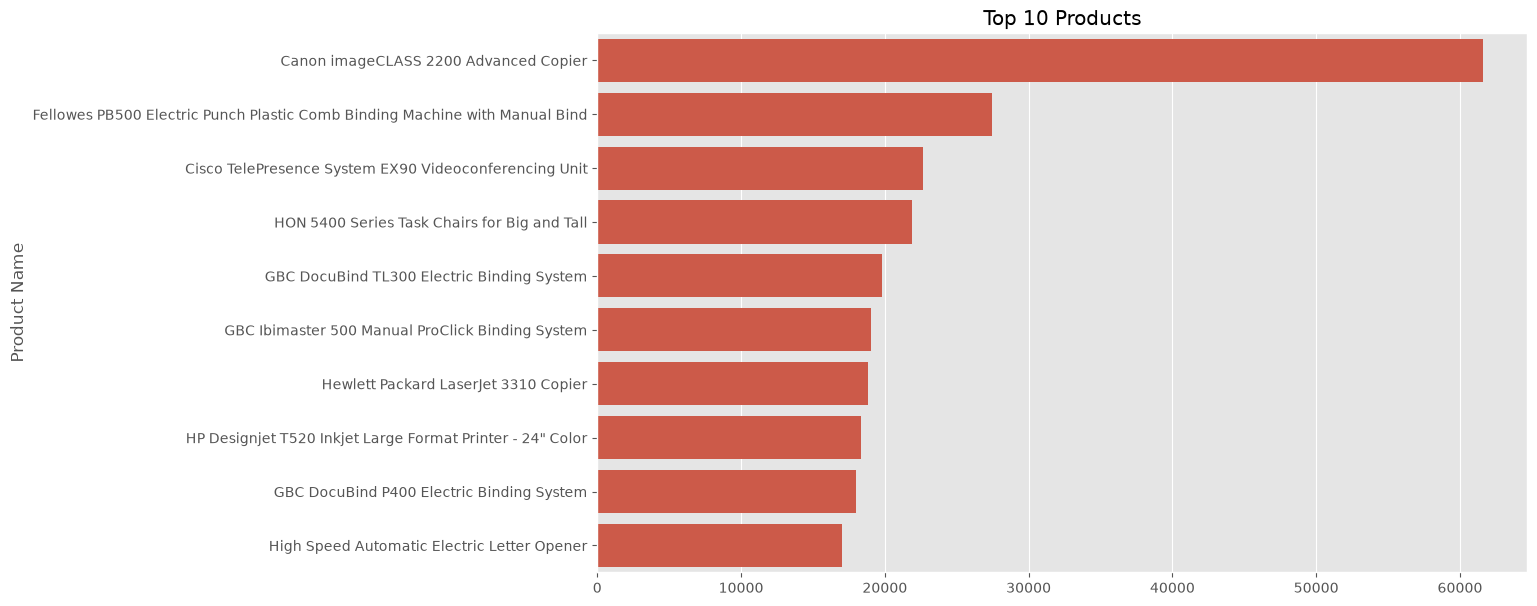

In [37]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products")
plt.savefig("../charts/top_products.png", dpi=300, bbox_inches="tight")

plt.show()

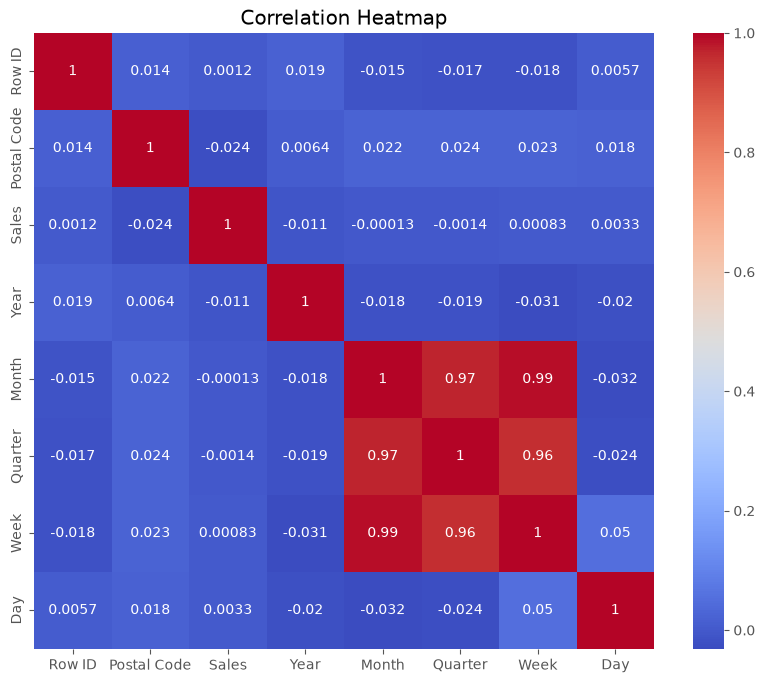

In [38]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("../charts/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

# Business Insights

## Key Findings

- Sales fluctuate throughout the year.
- Some states generate significantly higher revenue.
- Technology and Furniture contribute a large share of revenue.
- Consumer Segment contributes the largest sales.
- Standard Class shipping is the most commonly used.
- A small number of products account for a large percentage of total sales.

# Day 2 Summary

## Objective

Perform exploratory data analysis to understand business performance and sales behavior.

## Tasks Completed

- Loaded processed dataset.
- Performed exploratory data analysis.
- Visualized sales distribution.
- Analyzed yearly, quarterly, and monthly trends.
- Studied regional and state-wise sales.
- Explored product categories and subcategories.
- Compared customer segments.
- Analyzed shipping methods.
- Identified top-selling products.
- Created a correlation heatmap.
- Generated business insights.
- Saved charts for reports and dashboard.

## Outcome

The sales dataset has been thoroughly explored, and key business trends have been identified. The generated visualizations will support forecasting, anomaly detection, and dashboard development in the upcoming stages.